In [8]:
#challenge

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/hp/Desktop/DI_BOOTCAMP/week2/day4/dailyChallenge/Sample - Superstore.csv', encoding='latin1')

print(df.shape)
print(df.columns)

df.info()
df.describe()
df.isnull().sum()

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
df = df.drop_duplicates()

In [10]:
df['Postal Code'] = df['Postal Code'].fillna(0)

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

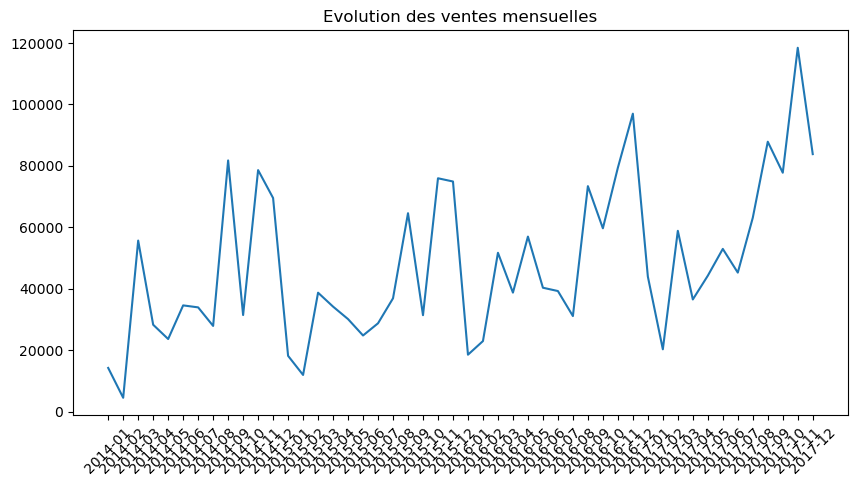

In [13]:
monthly_sales = df.groupby('Order Month-Year')['Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.xticks(rotation=45)
plt.title("Evolution des ventes mensuelles")
plt.show()

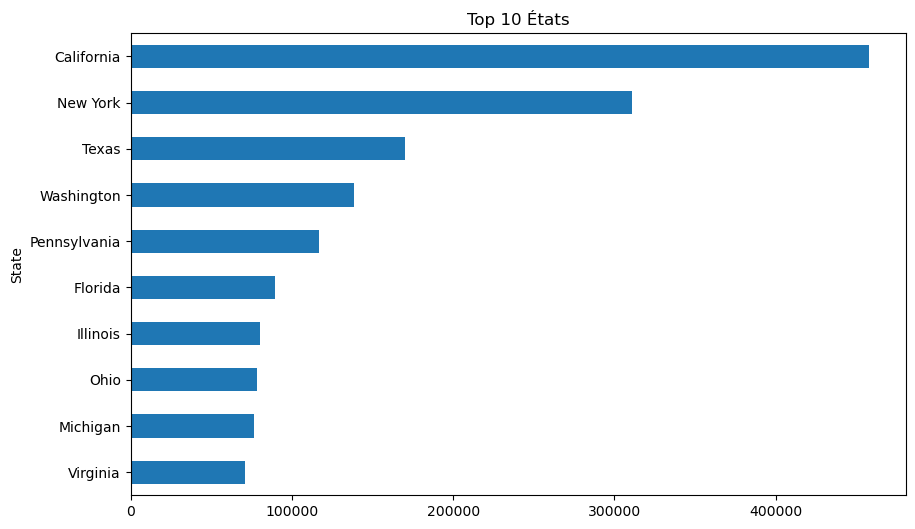

In [14]:
state_sales = df.groupby('State')['Sales'].sum().sort_values()

state_sales.tail(10).plot(kind='barh', figsize=(10,6))
plt.title("Top 10 États")
plt.show()

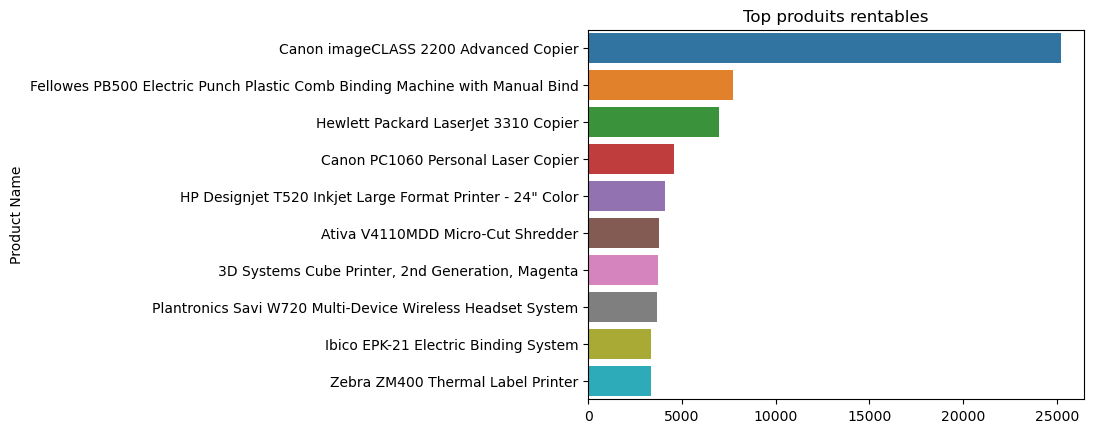

In [15]:
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=product_profit.values, y=product_profit.index)
plt.title("Top produits rentables")
plt.show()

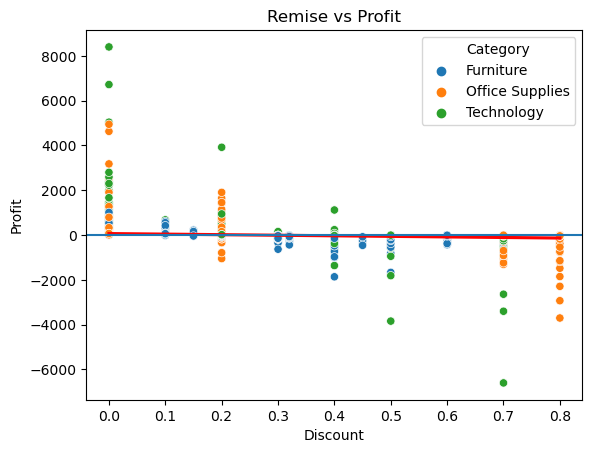

In [16]:
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red')

plt.axhline(0)
plt.title("Remise vs Profit")
plt.show()

📊 Performance globale :
- Chiffre d’affaires élevé mais marge variable

🗺️ Géographie :
- Les ventes sont concentrées dans quelques États

🏆 Produits :
- Certains produits génèrent la majorité du profit

💰 Remises :
- Les remises > 20% entraînent des pertes

📌 Recommandation :
- Limiter les remises à 20%
- Se concentrer sur les produits les plus rentables